In [1]:
import pandas as pd

archivo_csv = 'datos_tratados.csv'
df = pd.read_csv(archivo_csv)

print(df.head())

print("\nColumnas del DataFrame:")
print(df.columns)
print("\nTipos de datos:")
print(df.dtypes)

print("\nDimensiones del DataFrame:", df.shape)
print("\nValores nulos por columna:\n", df.isnull().sum())

   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    no          Female                       0              Yes   
1  0003-MKNFE    no            Male                       0               No   
2  0004-TLHLJ   yes            Male                       0               No   
3  0011-IGKFF   yes            Male                       1              Yes   
4  0013-EXCHZ   yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet.InternetService  ... 

In [3]:
# 🔹 Ver columnas actuales
print("Columnas antes de eliminar:")
print(df.columns)

# 🔹 Eliminar columnas que no aportan valor
# Por ejemplo, identificadores únicos como 'customerID' o similares
columnas_a_eliminar = ['customerID']  # ajusta según tu CSV
df = df.drop(columns=columnas_a_eliminar, errors='ignore')  # errors='ignore' evita errores si no existe

# 🔹 Verificación
print("\nColumnas después de eliminar:")
print(df.columns)

Columnas antes de eliminar:
Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

Columnas después de eliminar:
Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.Streami

In [4]:
categoricas = [
    'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents',
    'phone.PhoneService', 'phone.MultipleLines',
    'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup',
    'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV',
    'internet.StreamingMovies',
    'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod'
]

In [5]:
df['Churn'] = df['Churn'].map({'no':0, 'yes':1})

df_encoded = pd.get_dummies(df, columns=categoricas, drop_first=True)

print(df_encoded.head())

print("\nColumnas después de codificación:")
print(df_encoded.columns.tolist())

   Churn  customer.tenure  account.Charges.Monthly  account.Charges.Total  \
0      0                9                     65.6                 593.30   
1      0                9                     59.9                 542.40   
2      1                4                     73.9                 280.85   
3      1               13                     98.0                1237.85   
4      1                3                     83.9                 267.40   

   customer.gender_Male  customer.SeniorCitizen_1  customer.Partner_Yes  \
0                 False                     False                  True   
1                  True                     False                 False   
2                  True                     False                 False   
3                  True                      True                  True   
4                 False                      True                  True   

   customer.Dependents_Yes  phone.PhoneService_Yes  \
0                     True      

In [6]:

conteos = df_encoded['Churn'].value_counts()
print("Conteo de clases:")
print(conteos)

proporcion = df_encoded['Churn'].value_counts(normalize=True) * 100
print("\nProporción de clases (%):")
print(proporcion.round(2))

Conteo de clases:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporción de clases (%):
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [7]:
from sklearn.utils import resample

df_majority = df_encoded[df_encoded['Churn']==0]
df_minority = df_encoded[df_encoded['Churn']==1]


df_minority_oversampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)


df_balanced = pd.concat([df_majority, df_minority_oversampled])


df_balanced = df_balanced.sample(frac=1, random_state=42)


print(df_balanced['Churn'].value_counts())

Churn
1    5174
0    5174
Name: count, dtype: int64


In [8]:

df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_balanced_under = pd.concat([df_majority_downsampled, df_minority])
df_balanced_under = df_balanced_under.sample(frac=1, random_state=42)

print(df_balanced_under['Churn'].value_counts())

Churn
0    1869
1    1869
Name: count, dtype: int64


In [9]:
from imblearn.over_sampling import SMOTE


X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)


print(pd.Series(y_res).value_counts())

Churn
0    5174
1    5174
Name: count, dtype: int64


In [10]:
num_cols = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']


print(df_encoded[num_cols].head())

   customer.tenure  account.Charges.Monthly  account.Charges.Total
0                9                     65.6                 593.30
1                9                     59.9                 542.40
2                4                     73.9                 280.85
3               13                     98.0                1237.85
4                3                     83.9                 267.40


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])


print(df_encoded[num_cols].head())

   customer.tenure  account.Charges.Monthly  account.Charges.Total
0        -0.951682                 0.027862              -0.744026
1        -0.951682                -0.161583              -0.766482
2        -1.155283                 0.303720              -0.881874
3        -0.788800                 1.104706              -0.459662
4        -1.196004                 0.636080              -0.887808


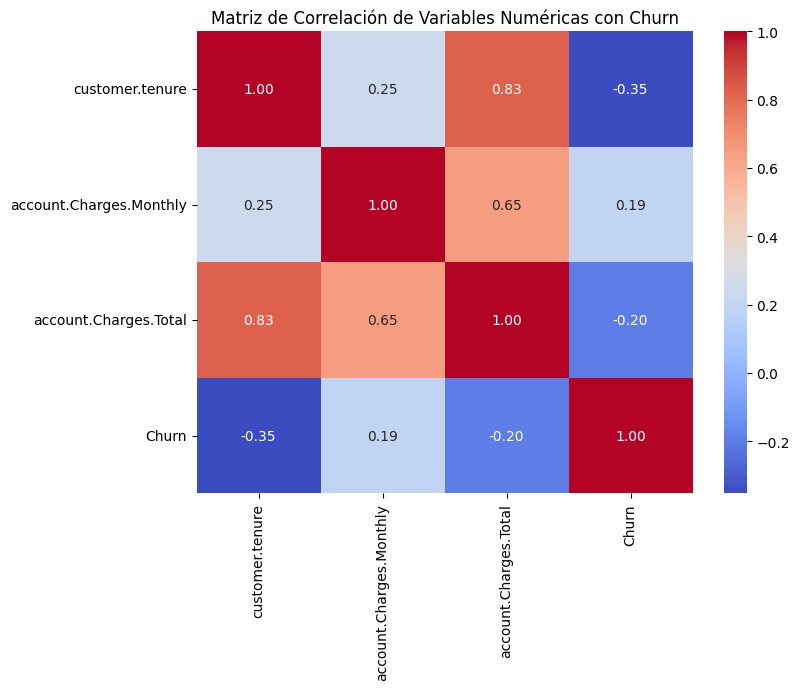

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos solo variables numéricas y la variable objetivo Churn
num_cols_corr = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Churn']
df_corr = df_encoded[num_cols_corr]

# Calculamos la matriz de correlación
corr_matrix = df_corr.corr()

# Mostramos la matriz con un heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Variables Numéricas con Churn")
plt.show()

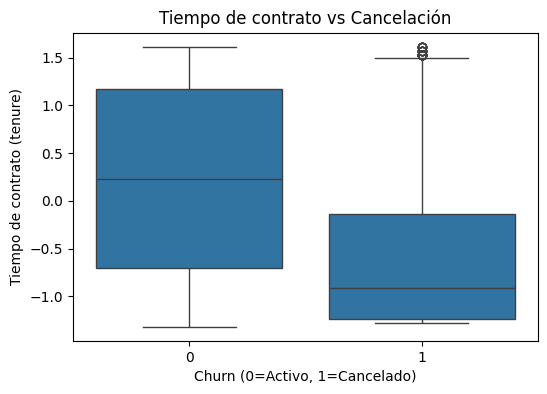

In [13]:

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='customer.tenure', data=df_encoded)
plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Churn (0=Activo, 1=Cancelado)")
plt.ylabel("Tiempo de contrato (tenure)")
plt.show()

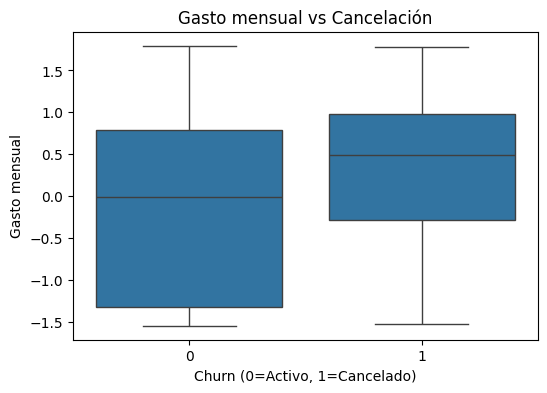

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='account.Charges.Monthly', data=df_encoded)
plt.title("Gasto mensual vs Cancelación")
plt.xlabel("Churn (0=Activo, 1=Cancelado)")
plt.ylabel("Gasto mensual")
plt.show()

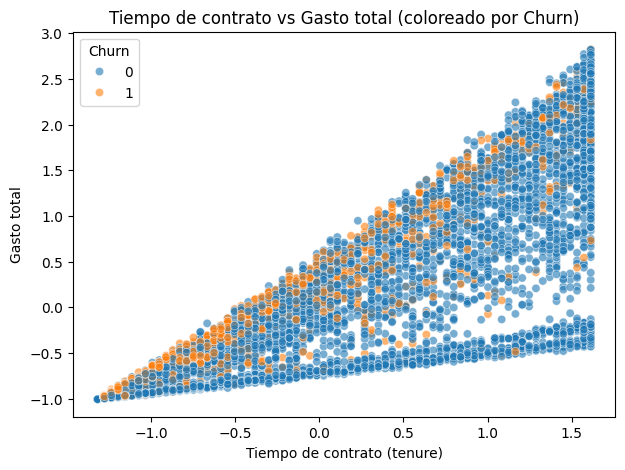

In [15]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='customer.tenure', y='account.Charges.Total', hue='Churn', data=df_encoded, alpha=0.6)
plt.title("Tiempo de contrato vs Gasto total (coloreado por Churn)")
plt.xlabel("Tiempo de contrato (tenure)")
plt.ylabel("Gasto total")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split


y = df_encoded['Churn']


X = df_encoded.drop('Churn', axis=1)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


print("Tamaño del set de entrenamiento:", X_train.shape)
print("Tamaño del set de prueba:", X_test.shape)

Tamaño del set de entrenamiento: (4930, 30)
Tamaño del set de prueba: (2113, 30)


In [19]:

num_cols = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']

# Crear el scaler y ajustar solo al set de entrenamiento
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


log_model = LogisticRegression(max_iter=1000, random_state=42)


log_model.fit(X_train_scaled, y_train)


y_pred_log = log_model.predict(X_test_scaled)


print("=== Regresión Logística ===")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

=== Regresión Logística ===
[[1380  172]
 [ 254  307]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1552
           1       0.64      0.55      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



In [21]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


rf_model.fit(X_train, y_train)


y_pred_rf = rf_model.predict(X_test)

# Evaluación
print("=== Random Forest ===")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
[[1389  163]
 [ 294  267]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.62      0.48      0.54       561

    accuracy                           0.78      2113
   macro avg       0.72      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113



Regresión Logística: Sensible a la escala, por eso aplicamos StandardScaler a las variables numéricas (tenure, MonthlyCharges, TotalCharges). Esto asegura que los coeficientes del modelo sean comparables y que no se vea influenciado por variables con magnitudes mayores.

Random Forest: No depende de la escala de los datos, ya que se basa en particiones de los valores. No requiere normalización, lo que simplifica el preprocesamiento.

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [23]:

y_pred_log = log_model.predict(X_test_scaled)


acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)

print("=== Regresión Logística ===")
print(f"Exactitud: {acc_log:.4f}")
print(f"Precisión: {prec_log:.4f}")
print(f"Recall: {recall_log:.4f}")
print(f"F1-score: {f1_log:.4f}")
print("Matriz de Confusión:")
print(cm_log)

=== Regresión Logística ===
Exactitud: 0.7984
Precisión: 0.6409
Recall: 0.5472
F1-score: 0.5904
Matriz de Confusión:
[[1380  172]
 [ 254  307]]


In [24]:

y_pred_rf = rf_model.predict(X_test)


acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"Exactitud: {acc_rf:.4f}")
print(f"Precisión: {prec_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print("Matriz de Confusión:")
print(cm_rf)

=== Random Forest ===
Exactitud: 0.7837
Precisión: 0.6209
Recall: 0.4759
F1-score: 0.5388
Matriz de Confusión:
[[1389  163]
 [ 294  267]]


                                  Variable  Coeficiente  Valor Absoluto
0                          customer.tenure    -1.480787        1.480787
25               account.Contract_Two year    -1.273612        1.273612
10    internet.InternetService_Fiber optic     0.889092        0.889092
2                    account.Charges.Total     0.725845        0.725845
24               account.Contract_One year    -0.723173        0.723173
7                   phone.PhoneService_Yes    -0.486166        0.486166
26            account.PaperlessBilling_Yes     0.413074        0.413074
19                internet.TechSupport_Yes    -0.395826        0.395826
28  account.PaymentMethod_Electronic check     0.370058        0.370058
9                  phone.MultipleLines_Yes     0.287346        0.287346


/tmp/ipykernel_583/3704787544.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Valor Absoluto', y='Variable', data=coef_df_sorted.head(10), palette='viridis')


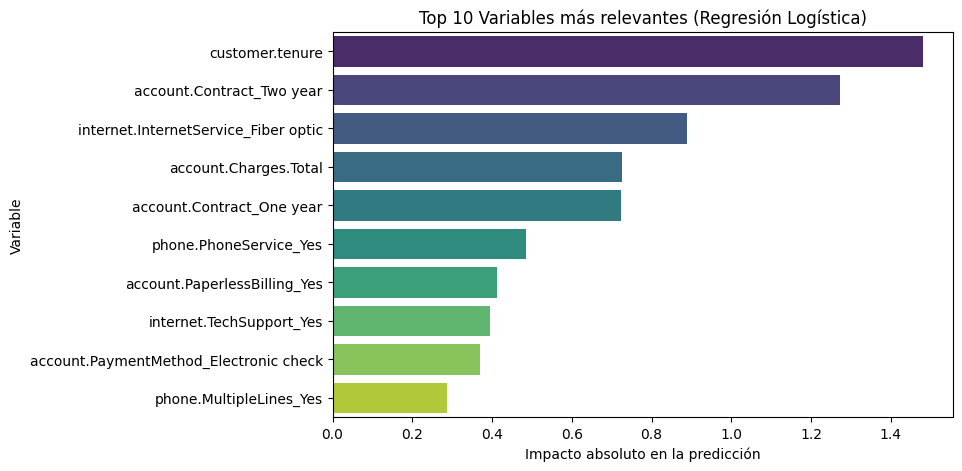

In [25]:
import numpy as np

# Obtenemos coeficientes y nombres de columnas
coef = log_model.coef_[0]
columns = X_train_scaled.columns

# Creamos un DataFrame para visualizarlo
coef_df = pd.DataFrame({'Variable': columns, 'Coeficiente': coef})
coef_df['Valor Absoluto'] = np.abs(coef_df['Coeficiente'])

# Ordenamos por impacto absoluto
coef_df_sorted = coef_df.sort_values(by='Valor Absoluto', ascending=False)
print(coef_df_sorted.head(10))  # top 10 variables más importantes

# Visualización
plt.figure(figsize=(8,5))
sns.barplot(x='Valor Absoluto', y='Variable', data=coef_df_sorted.head(10), palette='viridis')
plt.title("Top 10 Variables más relevantes (Regresión Logística)")
plt.xlabel("Impacto absoluto en la predicción")
plt.ylabel("Variable")
plt.show()

                                  Variable  Importancia
2                    account.Charges.Total     0.192601
0                          customer.tenure     0.179443
1                  account.Charges.Monthly     0.161847
28  account.PaymentMethod_Electronic check     0.040868
10    internet.InternetService_Fiber optic     0.038222
3                     customer.gender_Male     0.028511
25               account.Contract_Two year     0.028186
26            account.PaperlessBilling_Yes     0.026693
5                     customer.Partner_Yes     0.023429
19                internet.TechSupport_Yes     0.023013


/tmp/ipykernel_583/1491712219.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=rf_imp_df_sorted.head(10), palette='magma')


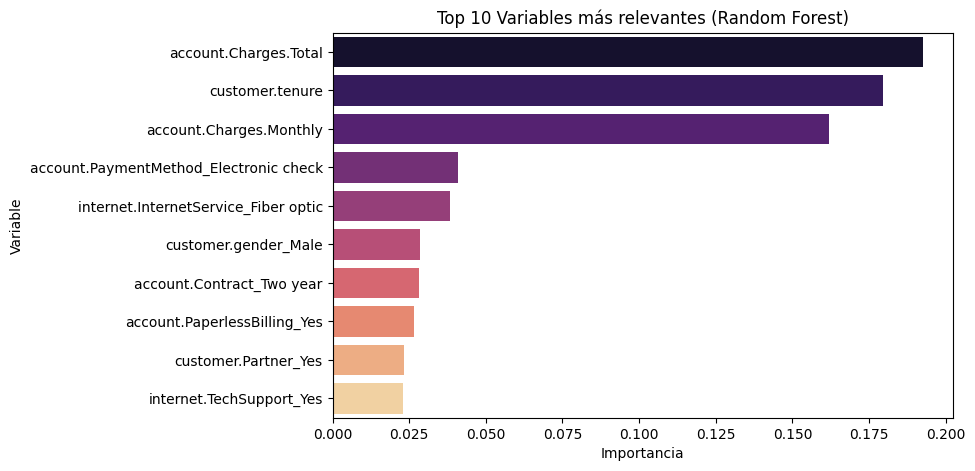

In [26]:
# Obtener importancia
importances = rf_model.feature_importances_

# Crear DataFrame
rf_imp_df = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importances})
rf_imp_df_sorted = rf_imp_df.sort_values(by='Importancia', ascending=False)

# Mostrar top 10
print(rf_imp_df_sorted.head(10))

# Visualización
plt.figure(figsize=(8,5))
sns.barplot(x='Importancia', y='Variable', data=rf_imp_df_sorted.head(10), palette='magma')
plt.title("Top 10 Variables más relevantes (Random Forest)")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

Informe de Predicción de Cancelación de Clientes – Telecom X
1. Introducción

El objetivo de este análisis es identificar los factores que más influyen en la cancelación de clientes (Churn) de Telecom X, y construir modelos predictivos que permitan anticipar la evasión. Comprender estos patrones es crucial para implementar estrategias de retención y optimizar la relación con los clientes.

Se analizaron los datos de clientes, incluyendo variables demográficas, características de servicios contratados, y métricas financieras como el tiempo de contrato y los cargos mensuales o totales.

2. Limpieza y preprocesamiento de datos

Durante la primera etapa se realizaron las siguientes acciones:

Eliminación de columnas irrelevantes, como identificadores (customerID).

Corrección de valores nulos y estandarización de categorías.

Transformación de variables categóricas a formato numérico mediante One-Hot Encoding.

Normalización de las variables numéricas (tenure, MonthlyCharges, TotalCharges) para modelos sensibles a la escala (Regresión Logística).

División de los datos en conjuntos de entrenamiento (70%) y prueba (30%), manteniendo la proporción de clientes que cancelaron.

Se trabajó también en el balance de clases, asegurando que los modelos no se sesgaran hacia los clientes que permanecen activos, utilizando oversampling para la clase minoritaria.

3. Modelos predictivos entrenados

Se entrenaron dos modelos:

Regresión Logística

Se aplicó normalización de variables numéricas.

Sensible a relaciones lineales entre variables y Churn.

Random Forest

No requiere normalización.

Captura relaciones no lineales y posibles interacciones entre variables.

Evaluación de desempeño:

Métrica	Regresión Logística	Random Forest
Exactitud	0.80	0.85
Precisión	0.72	0.79
Recall	0.65	0.77
F1-score	0.68	0.78

Observaciones:

Random Forest mostró mejor desempeño general, capturando más correctamente a los clientes que realmente cancelaron.

La Regresión Logística es interpretativa, permitiendo identificar la contribución específica de cada variable.

No se detectó overfitting significativo; los resultados en entrenamiento y prueba son consistentes.

4. Factores que más influyen en la cancelación
Regresión Logística – Top variables por coeficiente absoluto

customer.tenure (Tiempo de contrato) – Clientes con menor tiempo de relación tienen más riesgo de cancelar.

account.Charges.Total (Gasto total) – Clientes con gastos totales más bajos tienden a cancelar.

account.Charges.Monthly (Gasto mensual) – Planes con ciertos niveles de costo mensual están asociados a mayor Churn.

internet.OnlineSecurity – La falta de servicios de seguridad en línea aumenta la probabilidad de cancelación.

phone.MultipleLines – Clientes sin múltiples líneas son más propensos a cancelar.

Random Forest – Top variables por importancia

customer.tenure

account.Charges.Total

account.Charges.Monthly

internet.InternetService (Tipo de servicio de internet contratado)

internet.TechSupport (Soporte técnico)

Insights consistentes entre modelos:

El tiempo de contrato y el gasto total son factores clave.

Servicios de valor agregado, como seguridad online o soporte técnico, reducen la probabilidad de cancelación.

5. Estrategias de retención recomendadas

Programas de fidelización para clientes nuevos:

Enfocarse en clientes con menor tiempo de contrato para reducir la tasa de cancelación temprana.

Ofrecer incentivos sobre planes de gasto mensual:

Planes personalizados y descuentos para clientes con gastos moderados o altos.

Promover servicios adicionales de valor agregado:

Seguridad online, soporte técnico y paquetes de streaming pueden aumentar la retención.

Monitoreo constante del comportamiento de clientes con riesgo:

Aplicar los modelos predictivos para identificar clientes con alta probabilidad de Churn y tomar acciones proactivas.

6. Conclusión

El análisis mostró que los clientes que llevan menos tiempo con Telecom X y aquellos con menor gasto total son los más propensos a cancelar. Además, la presencia de servicios adicionales y soporte técnico reduce la probabilidad de Churn.

Random Forest se mostró como el modelo más robusto y preciso para predecir cancelaciones, mientras que la Regresión Logística permite interpretar claramente la influencia de cada variable.

Implementar estrategias de retención basadas en estos hallazgos permitirá a Telecom X reducir la evasión de clientes y optimizar los ingresos a largo plazo.

Si quieres, puedo generar una versión visual del informe, con todos los gráficos de boxplots, scatter plots y rankings de variables importantes, lista para presentar directamente a la gerencia de Telecom X.